In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ModuleNotFoundError: No module named 'sklearn'

In [10]:
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load the dataset
df = pd.read_csv("car data.csv")

In [3]:
# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [5]:
# Statistical summary
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
# Check for missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
# Create Car_Age feature
df["Car_Age"] = 2026 - df["Year"]

# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [8]:
# Remove Year column
df.drop("Year", axis=1, inplace=True)

# Display the first 5 rows
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [11]:
# Create LabelEncoder object
encoder = LabelEncoder()

# Convert categorical columns into numeric values
df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])
df["Selling_type"] = encoder.fit_transform(df["Selling_type"])
df["Transmission"] = encoder.fit_transform(df["Transmission"])

In [12]:
# Display first 5 rows
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,2,0,1,0,12
1,sx4,4.75,9.54,43000,1,0,1,0,13
2,ciaz,7.25,9.85,6900,2,0,1,0,9
3,wagon r,2.85,4.15,5200,2,0,1,0,15
4,swift,4.60,6.87,42450,1,0,1,0,12


In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'ritz'

<Figure size 1000x800 with 0 Axes>

In [14]:
df.columns

Index(['Car_Name', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='str')

In [15]:
df.drop("Car_Name", axis=1, inplace=True)

In [16]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='str')

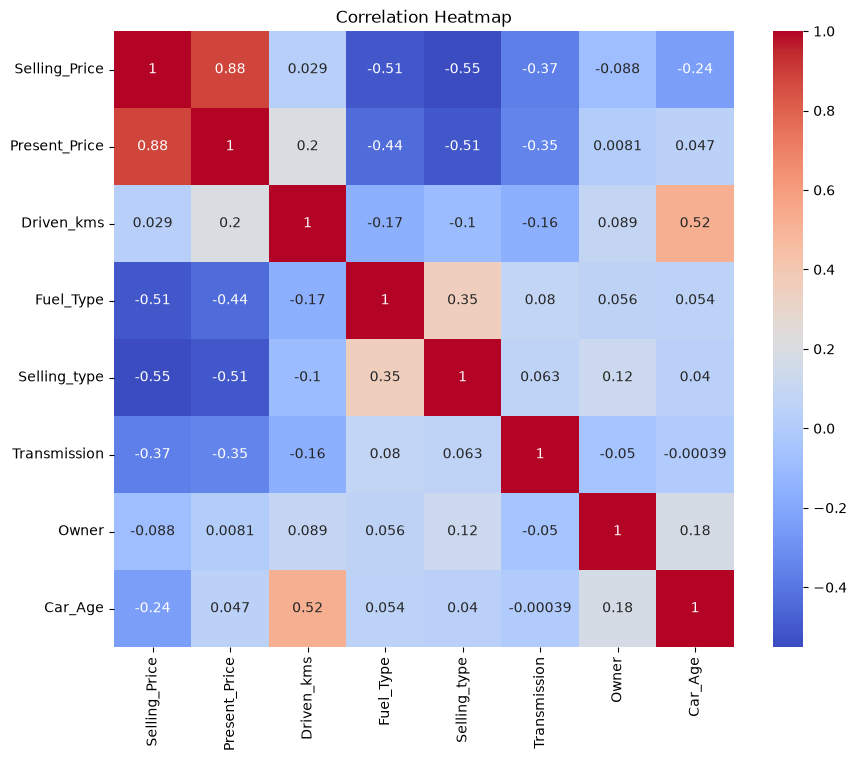

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Features (X) and Target (y)
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# Display first 5 rows of X
X.head()

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,5.59,27000,2,0,1,0,12
1,9.54,43000,1,0,1,0,13
2,9.85,6900,2,0,1,0,9
3,4.15,5200,2,0,1,0,15
4,6.87,42450,1,0,1,0,12


In [19]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

NameError: name 'train_test_split' is not defined

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 7)
Testing data: (61, 7)


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [23]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [24]:
# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("----- Linear Regression -----")
print("R2 Score :", r2_score(y_test, lr_pred))
print("MAE      :", mean_absolute_error(y_test, lr_pred))
print("MSE      :", mean_squared_error(y_test, lr_pred))

print("\n----- Random Forest -----")
print("R2 Score :", r2_score(y_test, rf_pred))
print("MAE      :", mean_absolute_error(y_test, rf_pred))
print("MSE      :", mean_squared_error(y_test, rf_pred))

----- Linear Regression -----
R2 Score : 0.8466902419663827
MAE      : 1.221932362175385
MSE      : 3.531579888968638

----- Random Forest -----
R2 Score : 0.9598535945512015
MAE      : 0.6364114754098363
MSE      : 0.924795915901639


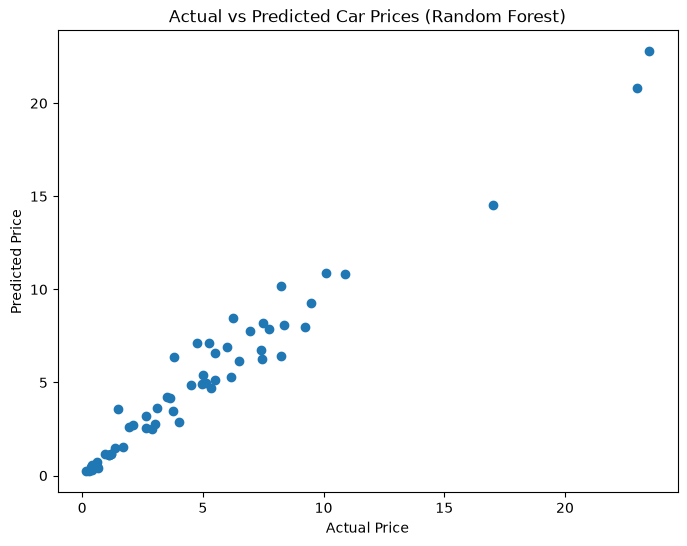

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices (Random Forest)")
plt.show()

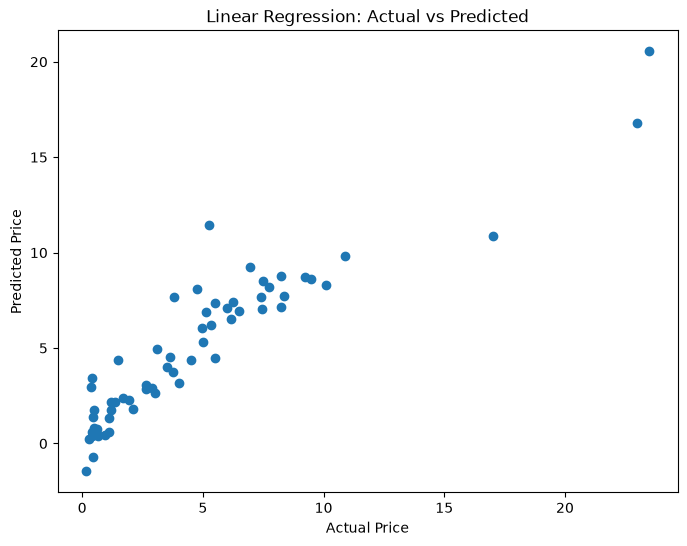

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

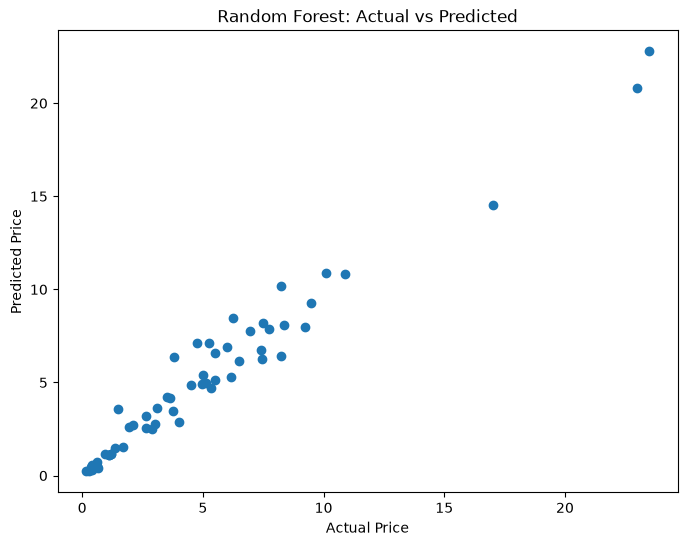

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [29]:
import joblib

joblib.dump(rf, "car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [30]:
import joblib

loaded_model = joblib.load("car_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [31]:
import pandas as pd

new_car = pd.DataFrame({
    "Present_Price": [8.5],
    "Driven_kms": [35000],
    "Fuel_Type": [2],       # Petrol
    "Selling_type": [0],    # Dealer
    "Transmission": [1],    # Manual
    "Owner": [0],
    "Car_Age": [5]
})

prediction = loaded_model.predict(new_car)

print("Predicted Selling Price:", prediction[0], "Lakhs")

Predicted Selling Price: 6.652499999999996 Lakhs
